# Explore dense modeling results

Assumes results live under `../runs/`.

In [59]:
from pathlib import Path
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RUNS = (Path('..') / 'runs').resolve()
RUNS

PosixPath('/Users/spangher/Projects/stanford-research/norm-research/runs')

## Index available subsets

In [60]:
subset_dirs = sorted(RUNS.glob('**/subset_*'))
pd.DataFrame({'subset_dir': [str(p) for p in subset_dirs]})

,subset_dir
0,/Users/spangher/Projects/stanford-research/nor...
1,/Users/spangher/Projects/stanford-research/nor...
2,/Users/spangher/Projects/stanford-research/nor...
3,/Users/spangher/Projects/stanford-research/nor...
4,/Users/spangher/Projects/stanford-research/nor...


## 1) Optimal hyperparameter settings (Optuna)

In [61]:
subset_dirs

[PosixPath('/Users/spangher/Projects/stanford-research/norm-research/runs/press_release_sweep_bradley_terry_llama-8b/subset_0p1'),
 PosixPath('/Users/spangher/Projects/stanford-research/norm-research/runs/press_release_sweep_llama-70b/subset_0p1'),
 PosixPath('/Users/spangher/Projects/stanford-research/norm-research/runs/press_release_sweep_llama-8b/subset_0p1'),
 PosixPath('/Users/spangher/Projects/stanford-research/norm-research/runs/press_release_sweep_llama-8b/subset_0p2'),
 PosixPath('/Users/spangher/Projects/stanford-research/norm-research/runs/press_release_sweep_llama-8b/subset_0p3')]

In [62]:
rows = []
for d in subset_dirs:
    best_path = d / 'optuna_best_params.json'
    if not best_path.exists():
        continue
    best = json.loads(best_path.read_text())
    test_path = d / 'optuna_best_trial_test_metrics.json'
    test = json.loads(test_path.read_text()) if test_path.exists() else {}
    run_root = d.parent.name
    subset = float(d.name.replace('subset_', '').replace('p', '.'))
    rows.append({
        'run_root': run_root,
        'subset': subset,
        'best_eval_auc': best.get('best_value'),
        'best_trial': best.get('best_trial_number'),
        'best_params': best.get('best_params'),
        'test_auc': (test.get('metrics') or {}).get('auc'),
        'test_f1': (test.get('metrics') or {}).get('f1'),
    })
optuna_df = pd.DataFrame(rows).sort_values(['run_root','subset'])
optuna_df


,run_root,subset,best_eval_auc,best_trial,best_params,test_auc,test_f1
0,press_release_sweep_llama-8b,0.1,0.667274,8,"{'batch_size': 2, 'gradient_accumulation_steps...",0.664553,0.599984
1,press_release_sweep_llama-8b,0.2,0.690184,3,"{'batch_size': 1, 'gradient_accumulation_steps...",0.683299,0.517147


### Hyperparameter analysis (from Optuna trials)
We load all `optuna_trials.csv` files and summarize which params are common among the top decile of trials (by objective value).


In [63]:
trial_rows = []
for d in subset_dirs:
    csv_path = d / 'optuna_trials.csv'
    if not csv_path.exists():
        continue
    df_trials = pd.read_csv(csv_path)
    if 'value' not in df_trials.columns:
        continue
    df_trials['run_root'] = d.parent.name
    df_trials['subset'] = float(d.name.replace('subset_', '').replace('p', '.'))
    trial_rows.append(df_trials)
all_trials = pd.concat(trial_rows, ignore_index=True) if trial_rows else pd.DataFrame()
all_trials.head()


,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_gradient_accumulation_steps,params_learning_rate,params_lora_alpha,params_lora_dropout,params_lora_r,params_lora_target_modules_subset,params_max_length,params_warmup_ratio,params_weight_decay,user_attrs_best_epoch,user_attrs_trial_output_dir,state,run_root,subset
0,0,0.528613,2026-02-27 19:31:10.326081,2026-02-27 20:06:15.288584,0 days 00:35:04.962503,8,8,0.000011,64,0.161867,16,qv_only,256,0.020244,0.001482,3,runs/press_release_sweep_llama-8b/subset_0p1/t...,COMPLETE,press_release_sweep_llama-8b,0.1
1,1,0.655269,2026-02-27 20:06:15.297043,2026-02-27 21:07:58.134321,0 days 01:01:42.837278,8,8,0.000266,32,0.188510,8,qv_only,512,0.079287,0.000013,3,runs/press_release_sweep_llama-8b/subset_0p1/t...,COMPLETE,press_release_sweep_llama-8b,0.1
2,2,0.598859,2026-02-27 21:07:58.140952,2026-02-27 22:08:33.502990,0 days 01:00:35.362038,4,2,0.000329,16,0.061347,32,all_modules,256,0.075790,0.000021,3,runs/press_release_sweep_llama-8b/subset_0p1/t...,COMPLETE,press_release_sweep_llama-8b,0.1
3,3,0.655748,2026-02-27 22:08:33.508809,2026-02-27 22:59:12.288891,0 days 00:50:38.780082,4,2,0.000114,64,0.032779,8,mlp_only,256,0.126592,0.000173,2,runs/press_release_sweep_llama-8b/subset_0p1/t...,COMPLETE,press_release_sweep_llama-8b,0.1
4,4,0.662796,2026-02-27 22:59:12.295960,2026-02-28 00:13:40.364380,0 days 01:14:28.068420,1,2,0.000013,128,0.196086,16,qv_only,512,0.071332,0.000014,3,runs/press_release_sweep_llama-8b/subset_0p1/t...,COMPLETE,press_release_sweep_llama-8b,0.1


In [64]:
import warnings
warnings.simplefilter("ignore")

In [65]:
if all_trials.empty:
    print('No optuna_trials.csv files found.')
else:
    # Top 10% by objective value within each run_root+subset
    top_rows = []
    for (run_root, subset), g in all_trials.groupby(['run_root','subset']):
        g = g.dropna(subset=['value'])
        if g.empty:
            continue
        cutoff = g['value'].quantile(0.9)
        top = g[g['value'] >= cutoff]
        top['run_root'] = run_root
        top['subset'] = subset
        top_rows.append(top)
    top_trials = pd.concat(top_rows, ignore_index=True) if top_rows else pd.DataFrame()

    # Param columns are prefixed with 'params_' in optuna_trials.csv
    param_cols = [c for c in all_trials.columns if c.startswith('params_')]
    if top_trials.empty:
        print('No top trials found (check value column).')
    else:
        summary = {}
        for c in param_cols:
            if top_trials[c].dtype == 'O':
                summary[c] = top_trials[c].value_counts().head(5)
            else:
                summary[c] = top_trials[c].describe()[['mean','50%','min','max']]
        summary


### Hyperparameter vs. performance plots
Scatter plots of Optuna objective value vs. each hyperparameter.


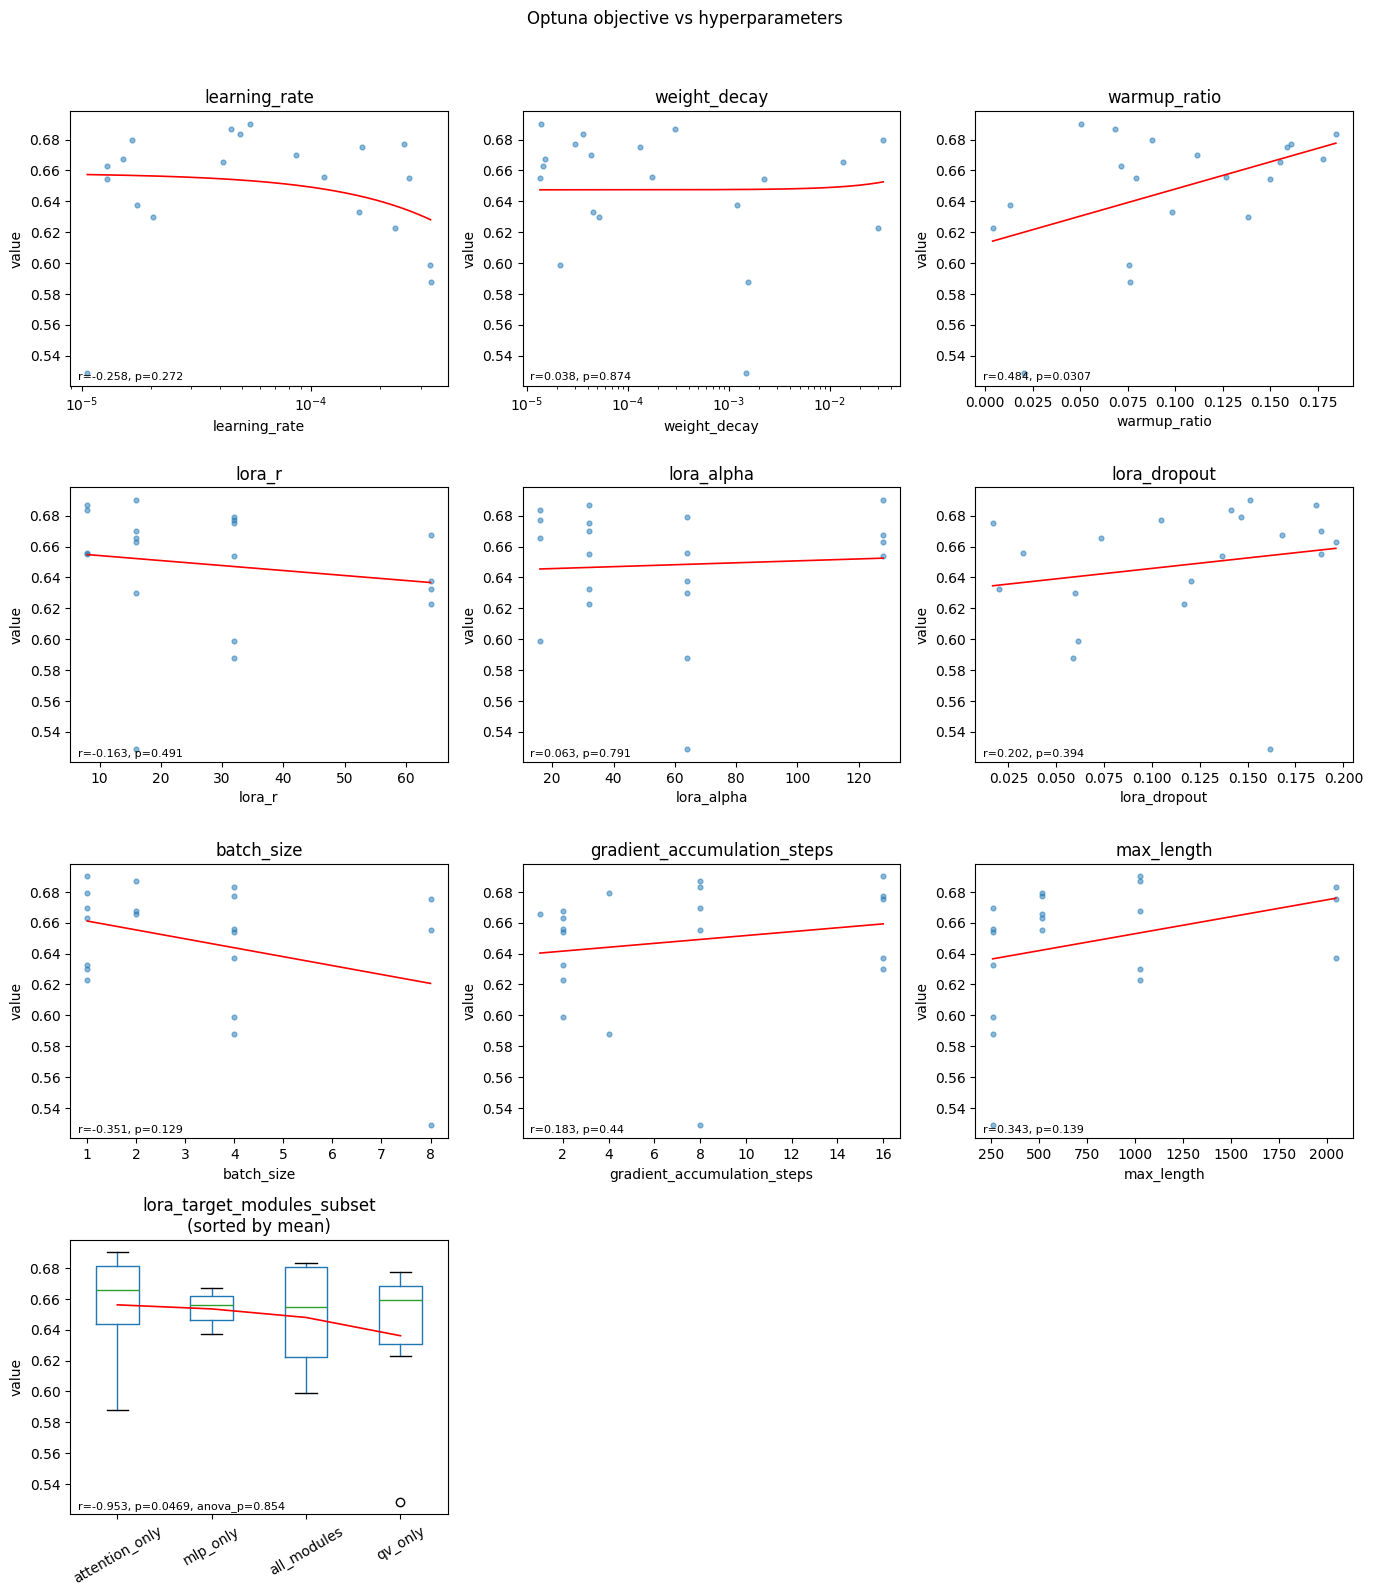

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
    has_scipy = True
except Exception:
    has_scipy = False

if all_trials.empty:
    print('No optuna_trials.csv files found.')
else:
    metric_col = 'value'
    plot_cols = [
        'params_learning_rate',
        'params_weight_decay',
        'params_warmup_ratio',
        'params_lora_r',
        'params_lora_alpha',
        'params_lora_dropout',
        'params_batch_size',
        'params_gradient_accumulation_steps',
        'params_max_length',
        'params_lora_target_modules_subset'
    ]
    plot_cols = [c for c in plot_cols if c in all_trials.columns]

    n = len(plot_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    plt.figure(figsize=(ncols * 4.6, nrows * 3.9))

    for i, col in enumerate(plot_cols, 1):
        ax = plt.subplot(nrows, ncols, i)
        x = all_trials[col]
        y = all_trials[metric_col]

        if pd.api.types.is_numeric_dtype(x):
            # numeric scatter + regression
            ax.scatter(x, y, alpha=0.5, s=12)
            ax.set_title(col.replace('params_', ''))
            ax.set_xlabel(col.replace('params_', ''))
            ax.set_ylabel(metric_col)
            if col in ('params_learning_rate', 'params_weight_decay'):
                ax.set_xscale('log')

            if has_scipy:
                slope, intercept, r, p, stderr = stats.linregress(x, y)
                xs = np.linspace(np.nanmin(x), np.nanmax(x), 200)
                ys = intercept + slope * xs
                ax.plot(xs, ys, color='red', linewidth=1.2)
                ax.text(0.02, 0.02, f'r={r:.3f}, p={p:.3g}', transform=ax.transAxes, fontsize=8)
            else:
                ax.text(0.02, 0.02, 'scipy not available', transform=ax.transAxes, fontsize=8)
        else:
            # categorical boxplot; only sort when not already ordered (lora_target_modules_subset)
            cat_df = pd.DataFrame({col: x, metric_col: y}).dropna(subset=[col])
            if col == 'params_lora_target_modules_subset':
                order = cat_df.groupby(col)[metric_col].mean().sort_values(ascending=False).index.tolist()
                order_note = 'sorted by mean'
            else:
                order = pd.unique(cat_df[col]).tolist()
                order_note = 'original order'

            cat_df[col] = pd.Categorical(cat_df[col], categories=order, ordered=True)
            cat_df.boxplot(column=metric_col, by=col, ax=ax, grid=False, rot=30)
            ax.set_title(col.replace('params_', '') + f'\n({order_note})')
            ax.set_xlabel('')
            ax.set_ylabel(metric_col)

            # plot mean line and stats on category index (interpret as trend only)
            means = cat_df.groupby(col)[metric_col].mean().reindex(order)
            x_pos = np.arange(len(order)) + 1
            ax.plot(x_pos, means.values, color='red', linewidth=1.2)

            if has_scipy and len(order) >= 2:
                slope, intercept, r, p, stderr = stats.linregress(np.arange(len(order)), means.values)
                # ANOVA significance across categories
                groups = [cat_df.loc[cat_df[col] == cat, metric_col].values for cat in order]
                anova_p = np.nan
                if len(groups) >= 2 and all(len(g) > 0 for g in groups):
                    try:
                        _, anova_p = stats.f_oneway(*groups)
                    except Exception:
                        anova_p = np.nan
                if np.isnan(anova_p):
                    ax.text(0.02, 0.02, f'r={r:.3f}, p={p:.3g}', transform=ax.transAxes, fontsize=8)
                else:
                    ax.text(0.02, 0.02, f'r={r:.3f}, p={p:.3g}, anova_p={anova_p:.3g}', transform=ax.transAxes, fontsize=8)
            else:
                ax.text(0.02, 0.02, 'scipy not available', transform=ax.transAxes, fontsize=8)

    plt.suptitle('Optuna objective vs hyperparameters', y=1.02)
    plt.tight_layout()
    plt.show()


In [67]:
# Compact table of top-decile param medians (numeric only)
if not all_trials.empty:
    param_cols = [c for c in all_trials.columns if c.startswith('params_')]
    num_cols = [c for c in param_cols if pd.api.types.is_numeric_dtype(all_trials[c])]
    if num_cols and not top_trials.empty:
        med = top_trials[num_cols].median().sort_values()
        med


## 2) Performance vs. training dataset size

In [68]:
rows = []
for d in subset_dirs:
    run_root = d.parent.name
    subset = float(d.name.replace('subset_', '').replace('p', '.'))
    trials = sorted(p for p in d.glob('trial_*') if p.is_dir())
    best_auc = None
    best_trial = None
    best_split = None
    for t in trials:
        hpath = t / 'training_history.json'
        if not hpath.exists():
            continue
        hist = json.loads(hpath.read_text())
        for key in ('eval_auc','test_auc'):
            vals = [row.get(key) for row in hist if key in row]
            vals = [v for v in vals if v is not None]
            if not vals:
                continue
            val = max(vals)
            if best_auc is None or val > best_auc:
                best_auc = float(val)
                best_trial = t
                best_split = key.replace('_auc','')
    if best_trial is None:
        continue
    log_path = best_trial / 'training_run.log'
    train_n = eval_n = test_n = None
    if log_path.exists():
        text = log_path.read_text(errors='ignore')
        m = re.search(r"Train: (\d+) \(original (\d+)\) \| Eval: (\d+) \| Test: (\d+)", text)
        if m:
            train_n, eval_n, test_n = int(m.group(1)), int(m.group(3)), int(m.group(4))
        else:
            m = re.search(r"Train samples: (\d+) \| Eval samples: (\d+) \| Test samples: (\d+)", text)
            if m:
                train_n, eval_n, test_n = int(m.group(1)), int(m.group(2)), int(m.group(3))
    rows.append({
        'run_root': run_root,
        'subset': subset,
        'best_auc': best_auc,
        'best_split': best_split,
        'train_size': train_n,
        'eval_size': eval_n,
        'test_size': test_n,
        'is_bt': ('bradley' in run_root.lower()) or ('bt' in run_root.lower()),
    })
perf_df = pd.DataFrame(rows).sort_values(['run_root','subset'])
perf_df


,run_root,subset,best_auc,best_split,train_size,eval_size,test_size,is_bt
0,press_release_sweep_bradley_terry_llama-8b,0.1,0.638860,eval,10250,12813,12814,True
1,press_release_sweep_llama-70b,0.1,0.638894,eval,10250,12813,12814,False
2,press_release_sweep_llama-8b,0.1,0.667274,eval,10250,12813,12814,False
3,press_release_sweep_llama-8b,0.2,0.690184,eval,20501,12813,12814,False
4,press_release_sweep_llama-8b,0.3,0.693271,eval,30751,12813,12814,False


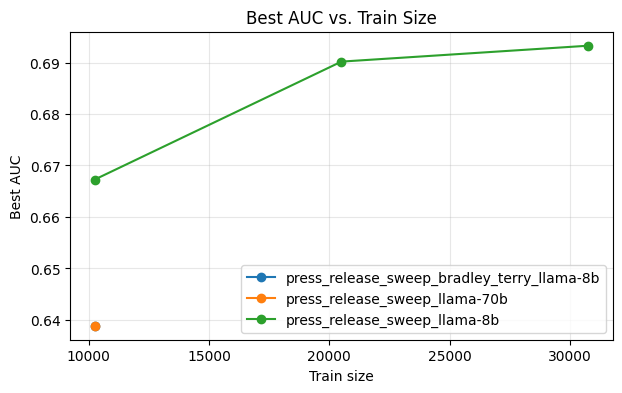

In [69]:
plt.figure(figsize=(7,4))
for run_root, g in perf_df.dropna(subset=['train_size']).groupby('run_root'):
    plt.plot(g['train_size'], g['best_auc'], marker='o', label=run_root)
plt.xlabel('Train size')
plt.ylabel('Best AUC')
plt.title('Best AUC vs. Train Size')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3) Binary vs. Bradley–Terry

In [70]:
bt_df = perf_df[perf_df['is_bt'] == True]
bin_df = perf_df[perf_df['is_bt'] == False]
bt_df[['run_root','subset','train_size','best_auc']].head()

,run_root,subset,train_size,best_auc
0,press_release_sweep_bradley_terry_llama-8b,0.1,10250,0.63886


In [71]:
 bin_df[['run_root','subset','train_size','best_auc']].head()

,run_root,subset,train_size,best_auc
1,press_release_sweep_llama-70b,0.1,10250,0.638894
2,press_release_sweep_llama-8b,0.1,10250,0.667274
3,press_release_sweep_llama-8b,0.2,20501,0.690184
4,press_release_sweep_llama-8b,0.3,30751,0.693271


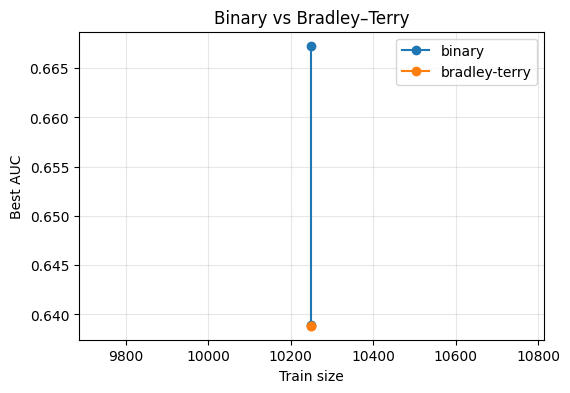

In [72]:
if not bt_df.empty and not bin_df.empty:
    merged = pd.merge(
        bin_df[['subset','train_size','best_auc']].rename(columns={'best_auc':'binary_auc'}),
        bt_df[['subset','train_size','best_auc']].rename(columns={'best_auc':'bt_auc'}),
        on=['subset','train_size'],
        how='inner'
    )
    merged
    plt.figure(figsize=(6,4))
    plt.plot(merged['train_size'], merged['binary_auc'], marker='o', label='binary')
    plt.plot(merged['train_size'], merged['bt_auc'], marker='o', label='bradley-terry')
    plt.xlabel('Train size')
    plt.ylabel('Best AUC')
    plt.title('Binary vs Bradley–Terry')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('Missing either BT or binary results. Check downloaded artifacts.')
